# Variance Reduction for Neural Posterior Estimation

The loss function we optimise is an expectation over the prior:
$$L(\phi) = \mathbb{E}_{p(\theta)}\!\Big[\,\lVert f_\phi\bigl(x(\theta)\bigr) - \theta\rVert^2\,\Big]$$

In practice we estimate this with mini-batches. The **variance of the gradient estimator** directly affects convergence speed and stability. This notebook investigates whether importance sampling (IS) and other variance-reduction techniques on the sampling distribution improve training.

**Techniques investigated:**
1. **Importance sampling** — Beta proposals that oversample boundary regions, with self-normalised weights
2. **Weight clipping** — truncating extreme IS weights to trade bias for reduced variance
3. **Antithetic IS** — pairing each IS sample with its mirror to induce negative correlation
4. **Stratified sampling** (Latin Hypercube) — guaranteed uniform coverage without any weights

**Testbed:** AR(1) model with $\rho \sim U(-1,1)$, $\sigma \sim U(0,5)$, $T=64$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import stats
from sbi import GRUEstimator, train, compare_models, heatmap_2d, simulate_ar1_batch

A = 5.0
T = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- AR(1) estimator ---
class AR1Estimator(GRUEstimator):
    def alter_outputs(self, x):
        rho = torch.tanh(x[:, 0])
        sigma = torch.exp(x[:, 1])
        return torch.stack([rho, sigma], dim=1)

# --- Sampling functions ---
def sample_uniform(batch_size):
    rho = torch.empty(batch_size).uniform_(-1, 1)
    sigma = torch.empty(batch_size).uniform_(0, A)
    x = simulate_ar1_batch(rho, sigma, T)
    return torch.stack([rho, sigma], dim=1), x

def sample_is(batch_size, alpha_rho=0.5, alpha_sigma=0.5):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, 1.0, size=batch_size)
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32)
    x = simulate_ar1_batch(rho, sigma, T)
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho)
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, 1.0)
    weights = torch.tensor(1.0 / (q_rho * q_sigma), dtype=torch.float32)
    return torch.stack([rho, sigma], dim=1), x, weights

# --- Shared uniform test set ---
np.random.seed(42); torch.manual_seed(42)
test_set = sample_uniform(8192)
print(f"Test set: {test_set[0].shape[0]} samples")

Device: cuda
Test set: 8192 samples


## 1. Gradient Variance Under Different Sampling Schemes

Before training, we measure the batch-to-batch variance of the **loss** and **gradient norm** at a fixed (randomly initialised) model. High gradient variance means the optimiser receives noisy signals, potentially slowing convergence or causing instability.

For IS, the self-normalised weighted loss is:
$$\hat{L}_\text{IS} = \frac{\sum_i w_i \lVert f_\phi(x_i) - \theta_i\rVert^2}{\sum_i w_i}, \quad w_i = \frac{p(\theta_i)}{q(\theta_i)}$$

Aggressive proposals (small $\alpha$) oversample boundaries but produce high-variance weights, which can *increase* gradient variance even as they improve coverage.

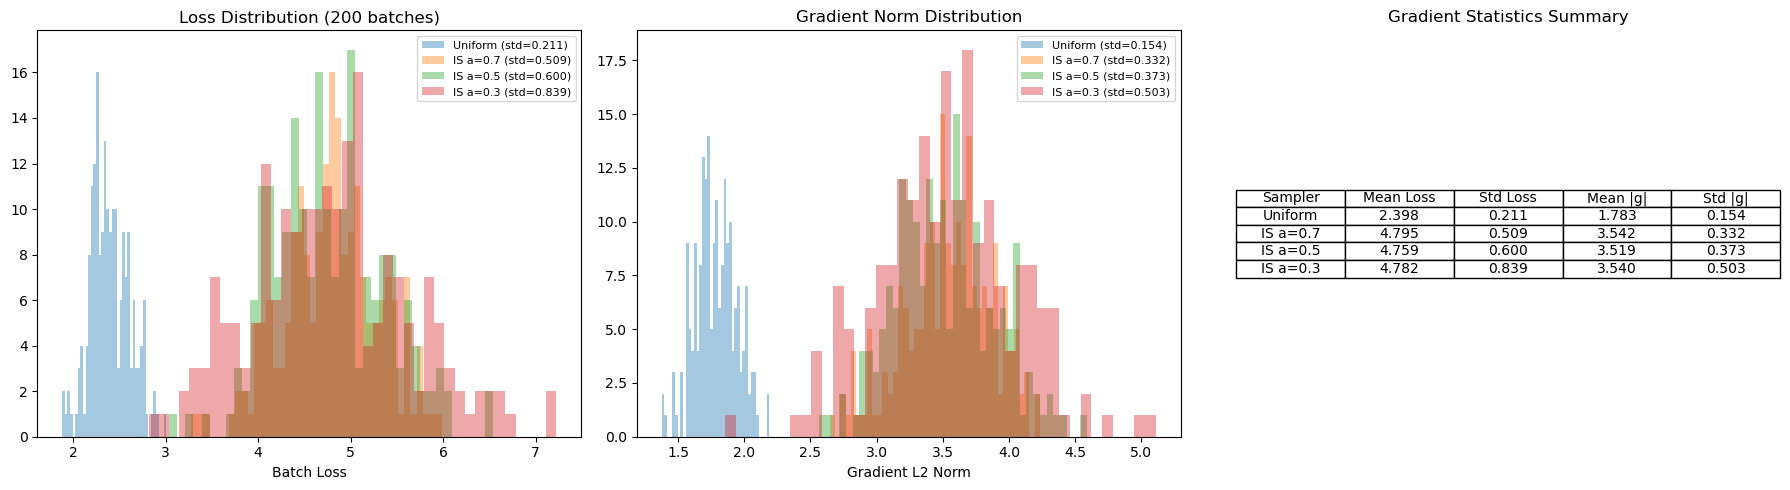

In [2]:
def measure_gradient_stats(model, sample_fns, n_batches=200, batch_size=128):
    """For a fixed model, measure per-batch loss and gradient norm under each sampler."""
    dev = next(model.parameters()).device
    results = {}

    for name, fn in sample_fns.items():
        losses, grad_norms = [], []
        for _ in range(n_batches):
            sample = fn(batch_size)
            theta_b = sample[0].float().to(dev) if isinstance(sample[0], torch.Tensor) \
                      else torch.tensor(sample[0], dtype=torch.float32, device=dev)
            x_b = sample[1].float().to(dev) if isinstance(sample[1], torch.Tensor) \
                  else torch.tensor(sample[1], dtype=torch.float32, device=dev)

            model.zero_grad()
            pred = model(x_b)

            if len(sample) == 3:
                w = sample[2].float().to(dev) if isinstance(sample[2], torch.Tensor) \
                    else torch.tensor(sample[2], dtype=torch.float32, device=dev)
                sq_err = ((pred - theta_b) ** 2).sum(dim=1)
                loss = (w * sq_err).sum() / w.sum()
            else:
                loss = nn.functional.mse_loss(pred, theta_b)

            loss.backward()
            losses.append(loss.item())
            total_norm = sum(p.grad.norm().item()**2
                            for p in model.parameters() if p.grad is not None) ** 0.5
            grad_norms.append(total_norm)

        results[name] = {'losses': np.array(losses), 'grad_norms': np.array(grad_norms)}
    return results

# Measure at a fresh model
torch.manual_seed(0)
probe_model = AR1Estimator().to(device)

samplers = {
    'Uniform':  sample_uniform,
    'IS a=0.7': lambda bs: sample_is(bs, 0.7, 0.7),
    'IS a=0.5': lambda bs: sample_is(bs, 0.5, 0.5),
    'IS a=0.3': lambda bs: sample_is(bs, 0.3, 0.3),
}
grad_stats = measure_gradient_stats(probe_model, samplers)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, s in grad_stats.items():
    axes[0].hist(s['losses'], bins=40, alpha=0.4, label=f"{name} (std={s['losses'].std():.3f})")
    axes[1].hist(s['grad_norms'], bins=40, alpha=0.4, label=f"{name} (std={s['grad_norms'].std():.3f})")

axes[0].set_xlabel('Batch Loss'); axes[0].set_title('Loss Distribution (200 batches)')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('Gradient L2 Norm'); axes[1].set_title('Gradient Norm Distribution')
axes[1].legend(fontsize=8)

# Summary table
ax = axes[2]; ax.axis('off')
rows = []
for name, s in grad_stats.items():
    l, g = s['losses'], s['grad_norms']
    rows.append([name, f'{l.mean():.3f}', f'{l.std():.3f}',
                 f'{g.mean():.3f}', f'{g.std():.3f}'])
table = ax.table(cellText=rows,
                 colLabels=['Sampler', 'Mean Loss', 'Std Loss', 'Mean |g|', 'Std |g|'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10)
ax.set_title('Gradient Statistics Summary')

plt.tight_layout(); plt.show()

## 2. Convergence Over Multiple Seeds

A single training run can be misleading. We train each method with 3 random seeds and plot mean $\pm$ 1 std of the test loss curve. This reveals whether IS produces **consistently** faster or more stable convergence, or whether the effect is within run-to-run noise.


=== Uniform ===
  Seed 0: final test MSE = 0.0371
  Seed 1: final test MSE = 0.0364
  Seed 2: final test MSE = 0.0370

=== IS a=0.7 ===
  Seed 0: final test MSE = 0.0404
  Seed 1: final test MSE = 0.0406
  Seed 2: final test MSE = 0.0385

=== IS a=0.5 ===
  Seed 0: final test MSE = 0.0374
  Seed 1: final test MSE = 0.0435
  Seed 2: final test MSE = 0.0383

=== IS a=0.3 ===
  Seed 0: final test MSE = 0.0410
  Seed 1: final test MSE = 0.0498
  Seed 2: final test MSE = 0.0367


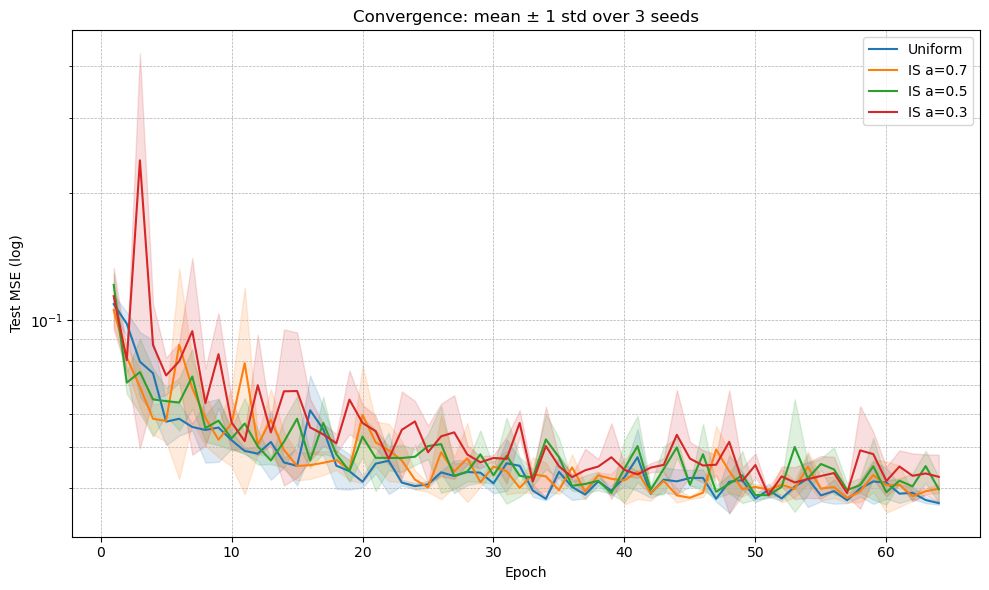


Convergence speed (epochs to reach MSE < 0.0405):
  Uniform        : epoch 24
  IS a=0.7       : epoch 25
  IS a=0.5       : epoch 36
  IS a=0.3       : epoch 51


In [3]:
N_SEEDS = 3
N_EPOCHS = 64
N_BATCHES = 128
LR = 2e-3

methods = {
    'Uniform':  sample_uniform,
    'IS a=0.7': lambda bs: sample_is(bs, 0.7, 0.7),
    'IS a=0.5': lambda bs: sample_is(bs, 0.5, 0.5),
    'IS a=0.3': lambda bs: sample_is(bs, 0.3, 0.3),
}

seed_results = {}   # {name: {'histories': [...], 'best_model': model}}

for name, fn in methods.items():
    print(f"\n=== {name} ===")
    histories = []
    best_model, best_loss = None, float('inf')

    for seed in range(N_SEEDS):
        m = AR1Estimator()
        m, h = train(m, fn, n_epochs=N_EPOCHS, n_batches=N_BATCHES, lr=LR,
                     seed=seed, test_set=test_set, verbose=False)
        histories.append(h)
        if h[-1] < best_loss:
            best_loss = h[-1]
            best_model = m
        print(f"  Seed {seed}: final test MSE = {h[-1]:.4f}")

    seed_results[name] = {'histories': histories, 'best_model': best_model}

# --- Plot convergence bands ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, (name, res) in enumerate(seed_results.items()):
    arr = np.array(res['histories'])  # (n_seeds, n_epochs)
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    epochs = np.arange(1, len(mean) + 1)
    ax.plot(epochs, mean, color=colors[i], label=name)
    ax.fill_between(epochs, mean - std, mean + std, color=colors[i], alpha=0.15)

ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test MSE (log)')
ax.set_title(f'Convergence: mean ± 1 std over {N_SEEDS} seeds')
ax.legend(); ax.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

# Convergence speed: epochs to reach 110% of best final MSE
threshold = min(np.array(res['histories']).mean(axis=0)[-1]
                for res in seed_results.values()) * 1.1
print(f"\nConvergence speed (epochs to reach MSE < {threshold:.4f}):")
for name, res in seed_results.items():
    arr = np.array(res['histories'])
    mean = arr.mean(axis=0)
    reached = np.where(mean < threshold)[0]
    epoch = reached[0] + 1 if len(reached) > 0 else '>max'
    print(f"  {name:15s}: epoch {epoch}")

## 3. Weight Clipping

Aggressive IS (small $\alpha$) produces large importance weights $w_i = p/q$. A few extreme weights can dominate the self-normalised loss, making gradients noisy. **Weight clipping** caps $w_i$ at a threshold $C$:
$$\tilde{w}_i = \min(w_i, C)$$

This introduces bias (we underweight the uniform-prior regions that IS downsampled) but reduces variance. We test IS $\alpha=0.3$ with clip thresholds $C \in \{5, 20, \infty\}$.

Training IS a=0.3 clip=5...
  Final test MSE: 0.0380
Training IS a=0.3 clip=20...
  Final test MSE: 0.0515
Training IS a=0.3 no clip...
  Final test MSE: 0.0515


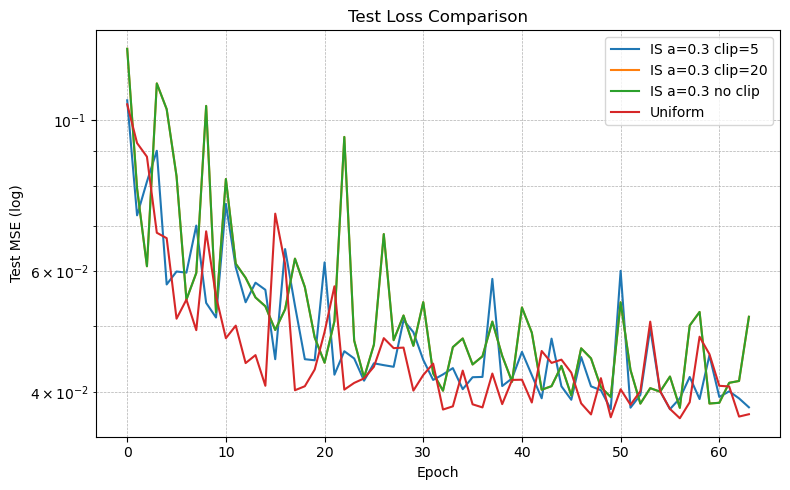

Model                      MSE($\rho$) MSE($\sigma$)      Total
-----------------------------------------------------------
IS a=0.3 clip=5                 0.0142       0.0618     0.0759
IS a=0.3 clip=20                0.0156       0.0874     0.1030
IS a=0.3 no clip                0.0156       0.0874     0.1030
Uniform                         0.0132       0.0595     0.0728


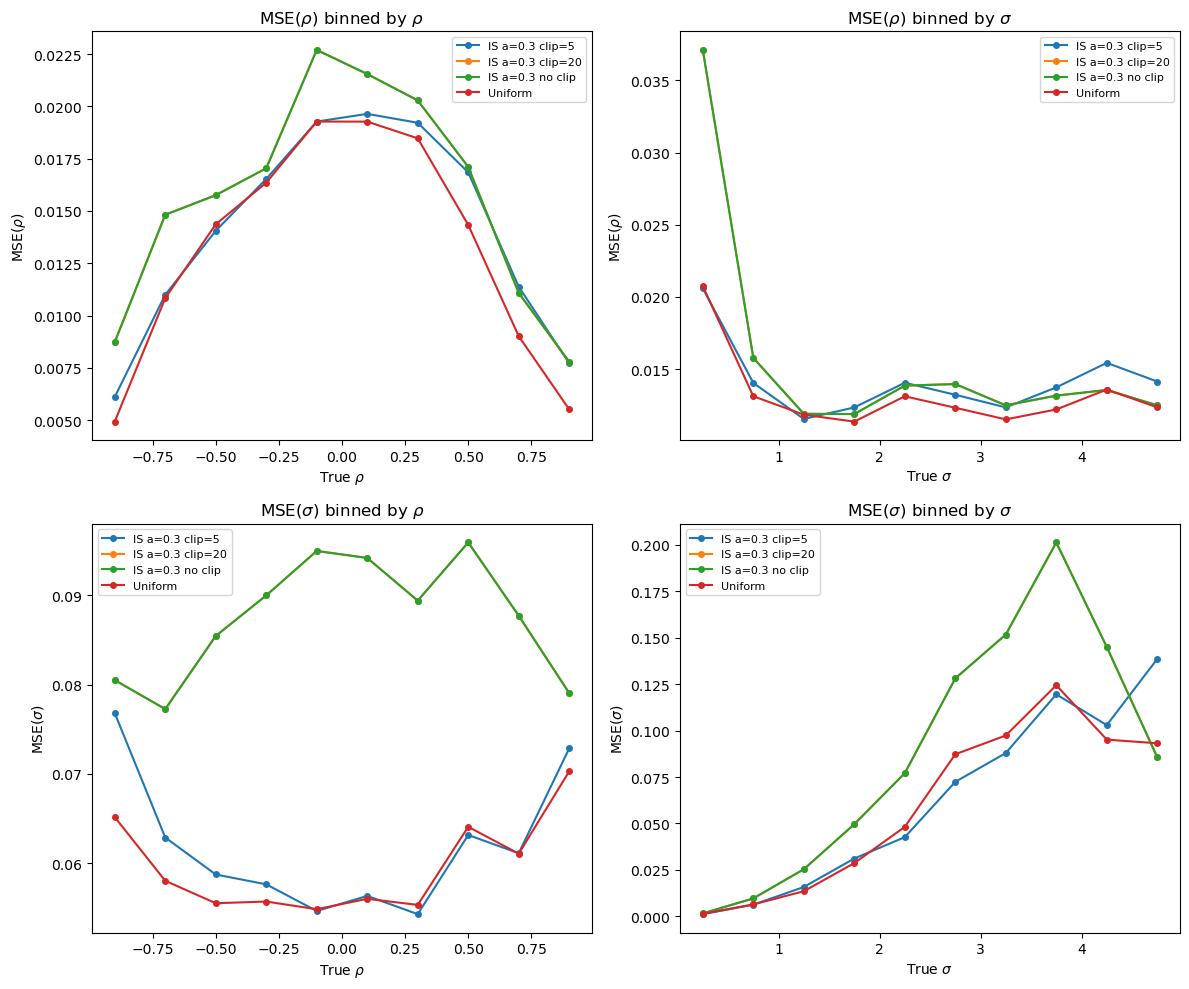

In [4]:
def make_is_clipped(alpha, clip_max):
    """Create an IS sampler with weight clipping."""
    def sampler(batch_size):
        theta, x, weights = sample_is(batch_size, alpha_rho=alpha, alpha_sigma=alpha)
        weights = weights.clamp(max=clip_max)
        return theta, x, weights
    return sampler

clip_models = {}
clip_histories = {}

for clip in [5, 20, float('inf')]:
    label = f'IS a=0.3 clip={clip}' if clip < float('inf') else 'IS a=0.3 no clip'
    print(f"Training {label}...")
    fn = make_is_clipped(0.3, clip)
    m = AR1Estimator()
    m, h = train(m, fn, n_epochs=N_EPOCHS, n_batches=N_BATCHES, lr=LR,
                 seed=0, test_set=test_set, verbose=False)
    clip_models[label] = m
    clip_histories[label] = h
    print(f"  Final test MSE: {h[-1]:.4f}")

# Add uniform baseline for reference
clip_models['Uniform'] = seed_results['Uniform']['best_model']
clip_histories['Uniform'] = seed_results['Uniform']['histories'][0]

compare_models(clip_models, clip_histories, test_set,
               [r'$\rho$', r'$\sigma$'], param_ranges=[(-1, 1), (0, A)])

## 4. Antithetic IS

Antithetic variates reduce variance by pairing negatively correlated samples. For a symmetric proposal $\rho' \sim \text{Beta}(\alpha,\alpha)$, if $u$ is one sample then $1-u$ has the same distribution. We construct each batch as **paired halves**: $(u_i, 1-u_i)$. When one sample lands near $\rho=+1$, its partner lands near $\rho=-1$ — the per-sample losses are negatively correlated, so their average has lower variance.

For $\sigma$ with $\text{Beta}(\alpha, 1)$, the transform $1-u$ gives $\text{Beta}(1, \alpha)$. The IS weights are still valid — we just use the correct proposal density for each sample.

a=0.7: Standard=0.0389  Antithetic=0.0368
a=0.5: Standard=0.0392  Antithetic=0.0422
a=0.3: Standard=0.0515  Antithetic=0.0380


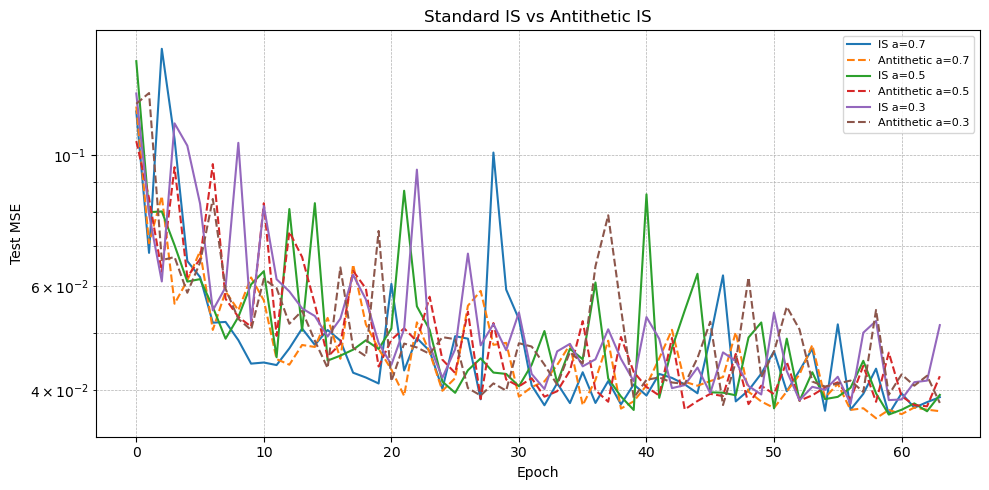

In [5]:
def sample_is_antithetic(batch_size, alpha_rho=0.5, alpha_sigma=0.5):
    """Antithetic IS: pair each (u, 1-u) for negatively correlated samples."""
    half = batch_size // 2

    # Original half
    u_rho = np.random.beta(alpha_rho, alpha_rho, size=half)
    u_sigma = np.random.beta(alpha_sigma, 1.0, size=half)

    # Antithetic half: (1-u) has Beta(b,a) distribution
    rho_tilde = np.concatenate([u_rho, 1 - u_rho])
    sigma_tilde = np.concatenate([u_sigma, 1 - u_sigma])

    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32)
    x = simulate_ar1_batch(rho, sigma, T)

    # Weights: original half uses Beta(a,a) and Beta(a,1) densities
    #          antithetic half uses Beta(a,a) (symmetric!) and Beta(1,a) densities
    q_rho_orig = stats.beta.pdf(u_rho, alpha_rho, alpha_rho)
    q_rho_anti = stats.beta.pdf(1 - u_rho, alpha_rho, alpha_rho)  # same for symmetric Beta
    q_sig_orig = stats.beta.pdf(u_sigma, alpha_sigma, 1.0)
    q_sig_anti = stats.beta.pdf(1 - u_sigma, 1.0, alpha_sigma)

    w_orig = 1.0 / (q_rho_orig * q_sig_orig)
    w_anti = 1.0 / (q_rho_anti * q_sig_anti)
    weights = torch.tensor(np.concatenate([w_orig, w_anti]), dtype=torch.float32)

    return torch.stack([rho, sigma], dim=1), x, weights

# Train antithetic IS alongside standard IS
anti_models = {}
anti_histories = {}

for alpha in [0.7, 0.5, 0.3]:
    # Standard IS
    label_std = f'IS a={alpha}'
    fn_std = lambda bs, a=alpha: sample_is(bs, a, a)
    m, h = train(AR1Estimator(), fn_std, n_epochs=N_EPOCHS, n_batches=N_BATCHES,
                 lr=LR, seed=0, test_set=test_set, verbose=False)
    anti_models[label_std] = m
    anti_histories[label_std] = h

    # Antithetic IS
    label_anti = f'Antithetic a={alpha}'
    fn_anti = lambda bs, a=alpha: sample_is_antithetic(bs, a, a)
    m, h = train(AR1Estimator(), fn_anti, n_epochs=N_EPOCHS, n_batches=N_BATCHES,
                 lr=LR, seed=0, test_set=test_set, verbose=False)
    anti_models[label_anti] = m
    anti_histories[label_anti] = h

    print(f"a={alpha}: Standard={anti_histories[label_std][-1]:.4f}  "
          f"Antithetic={anti_histories[label_anti][-1]:.4f}")

# Learning curves
plt.figure(figsize=(10, 5))
for name, h in anti_histories.items():
    ls = '--' if 'Antithetic' in name else '-'
    plt.plot(h, label=name, linestyle=ls)
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Test MSE')
plt.title('Standard IS vs Antithetic IS')
plt.legend(fontsize=8); plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

## 5. Stratified Sampling (Latin Hypercube)

An entirely different approach: instead of reweighting, ensure every batch has **guaranteed coverage** of the parameter space. Latin Hypercube Sampling (LHS) divides each parameter dimension into $N$ equal strata and places exactly one sample per stratum, with a random pairing across dimensions. This eliminates clustering gaps without needing any importance weights.

$$\theta_i^{(d)} = \frac{\pi(i) + U_i}{N} \cdot (\theta^{(d)}_\max - \theta^{(d)}_\min) + \theta^{(d)}_\min, \quad U_i \sim U(0,1)$$

where $\pi$ is a random permutation for each dimension.

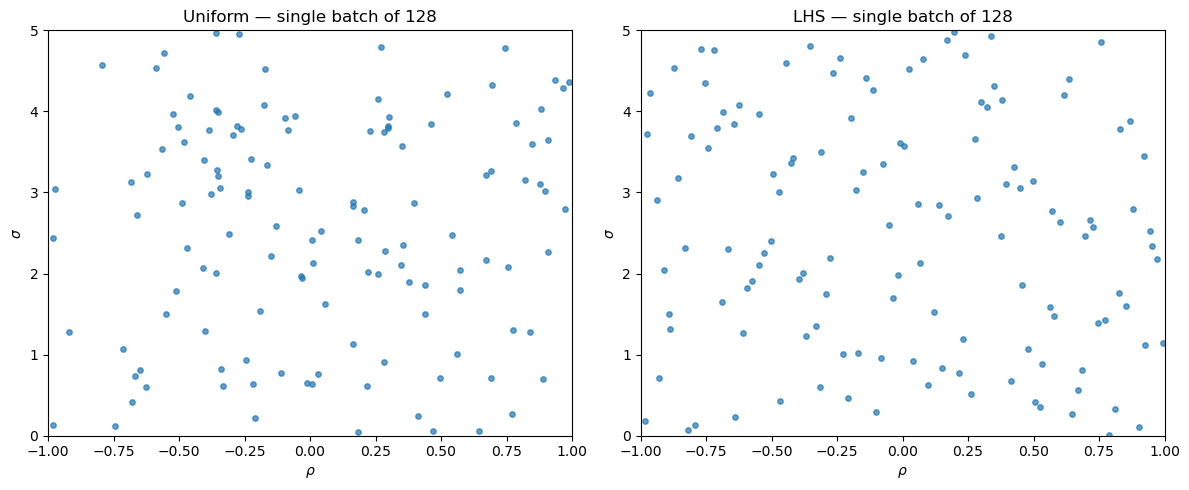

Training LHS...
  LHS final test MSE: 0.0464


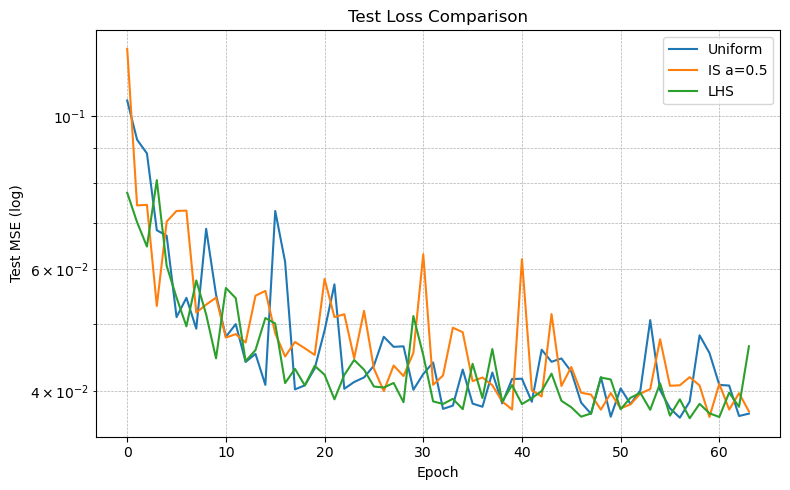

Model                      MSE($\rho$) MSE($\sigma$)      Total
-----------------------------------------------------------
Uniform                         0.0132       0.0595     0.0728
IS a=0.5                        0.0136       0.0611     0.0748
LHS                             0.0139       0.0789     0.0929


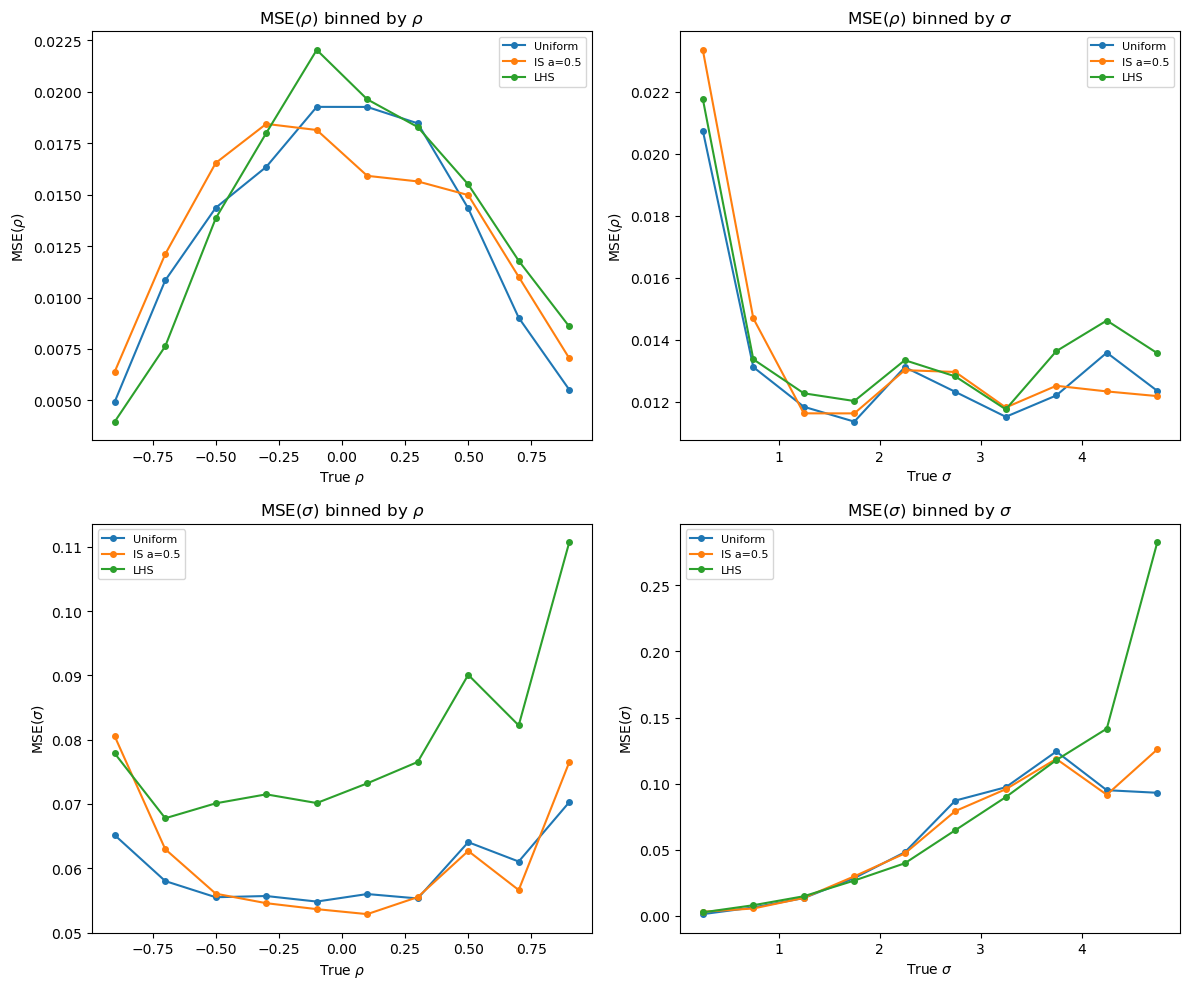

In [6]:
def sample_lhs(batch_size):
    """Latin Hypercube Sampling: one sample per stratum in each dimension."""
    n = batch_size
    # Stratified [0,1] samples for each parameter
    u_rho = (np.random.permutation(n) + np.random.uniform(0, 1, n)) / n
    u_sigma = (np.random.permutation(n) + np.random.uniform(0, 1, n)) / n

    rho = torch.tensor(2 * u_rho - 1, dtype=torch.float32)    # [-1, 1]
    sigma = torch.tensor(A * u_sigma, dtype=torch.float32)     # [0, A]
    x = simulate_ar1_batch(rho, sigma, T)
    return torch.stack([rho, sigma], dim=1), x  # no weights needed

# Visualise: uniform vs LHS coverage in a single batch
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
np.random.seed(0)
for ax, (name, fn) in zip(axes, [('Uniform', sample_uniform), ('LHS', sample_lhs)]):
    theta, _ = fn(128)
    theta_np = theta.numpy() if isinstance(theta, torch.Tensor) else theta
    ax.scatter(theta_np[:, 0], theta_np[:, 1], s=15, alpha=0.7)
    ax.set_xlabel(r'$\rho$'); ax.set_ylabel(r'$\sigma$')
    ax.set_title(f'{name} — single batch of 128')
    ax.set_xlim(-1, 1); ax.set_ylim(0, A)
plt.tight_layout(); plt.show()

# Train LHS vs Uniform
print("Training LHS...")
model_lhs, history_lhs = train(AR1Estimator(), sample_lhs,
                                n_epochs=N_EPOCHS, n_batches=N_BATCHES, lr=LR,
                                seed=0, test_set=test_set, verbose=False)
print(f"  LHS final test MSE: {history_lhs[-1]:.4f}")

# Compare
strat_models = {
    'Uniform': seed_results['Uniform']['best_model'],
    'IS a=0.5': seed_results['IS a=0.5']['best_model'],
    'LHS': model_lhs,
}
strat_histories = {
    'Uniform': seed_results['Uniform']['histories'][0],
    'IS a=0.5': seed_results['IS a=0.5']['histories'][0],
    'LHS': history_lhs,
}
compare_models(strat_models, strat_histories, test_set,
               [r'$\rho$', r'$\sigma$'], param_ranges=[(-1, 1), (0, A)])

## 6. Head-to-Head Comparison

We select the best variant from each category and compare them on the shared uniform test set:
- **Uniform** — baseline
- **IS $\alpha=0.5$** — moderate IS (best from Section 2)
- **IS $\alpha=0.3$ + clip=20** — aggressive IS with weight clipping (Section 3)
- **Antithetic IS $\alpha=0.5$** — variance-reduced IS (Section 4)
- **LHS** — stratified sampling, no weights (Section 5)

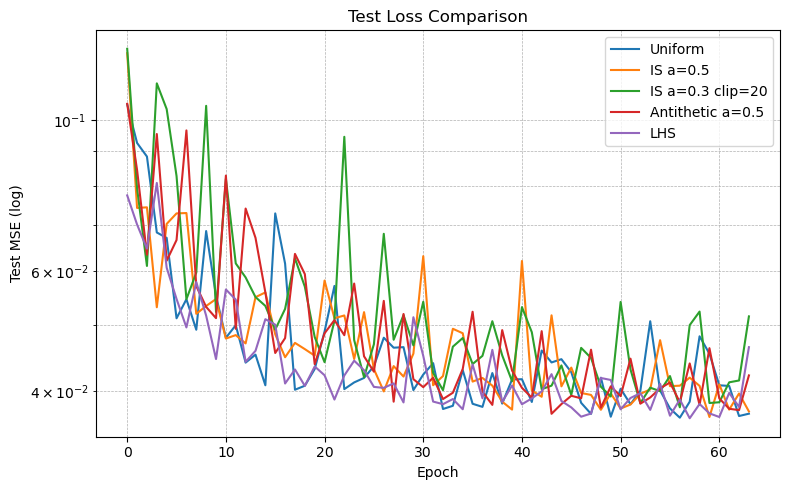

Model                      MSE($\rho$) MSE($\sigma$)      Total
-----------------------------------------------------------
Uniform                         0.0132       0.0595     0.0728
IS a=0.5                        0.0136       0.0611     0.0748
IS a=0.3 clip=20                0.0156       0.0874     0.1030
Antithetic a=0.5                0.0139       0.0705     0.0844
LHS                             0.0139       0.0789     0.0929


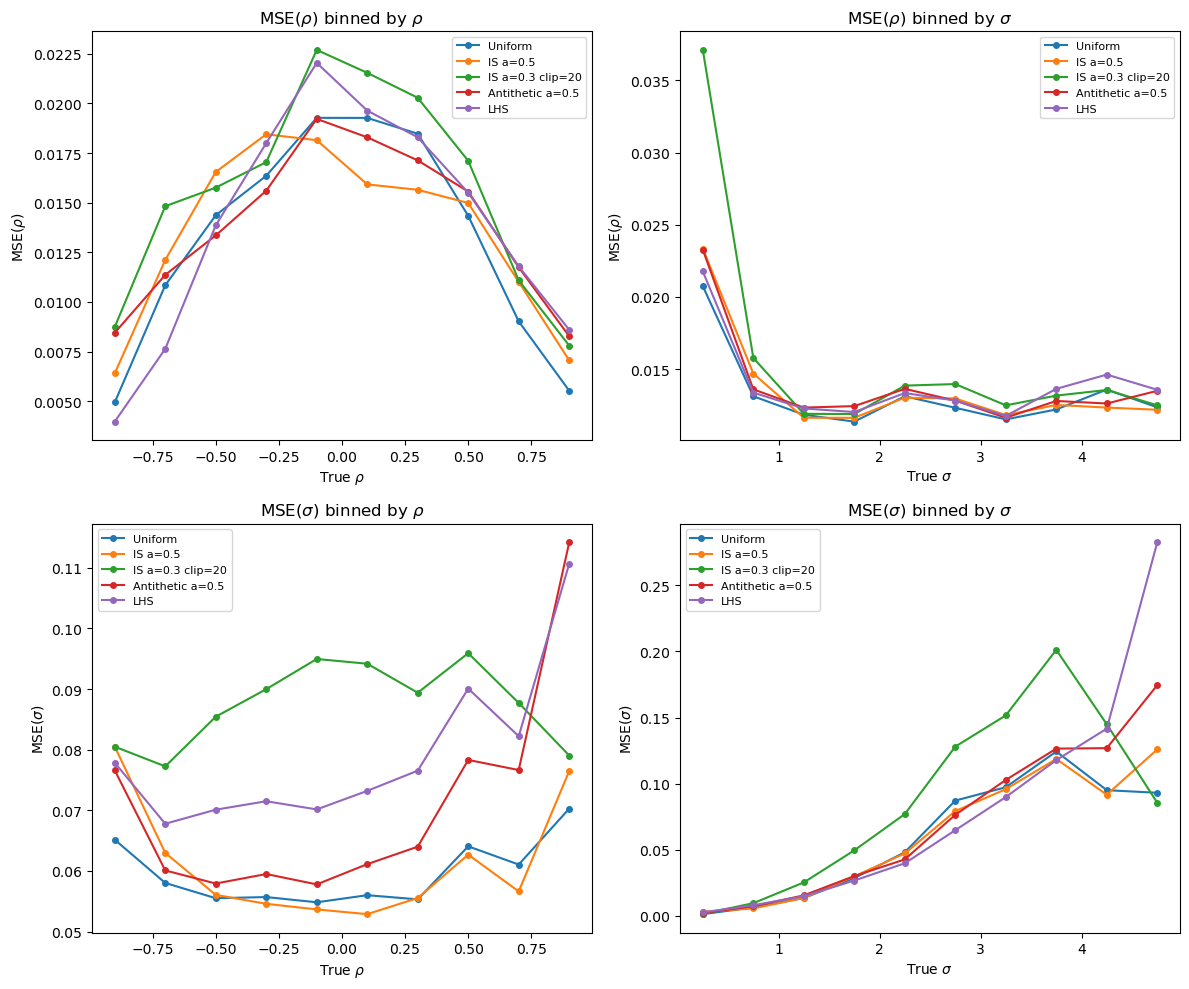

In [7]:
# Collect best model from each section
final_models = {
    'Uniform':              seed_results['Uniform']['best_model'],
    'IS a=0.5':             seed_results['IS a=0.5']['best_model'],
    'IS a=0.3 clip=20':     clip_models.get('IS a=0.3 clip=20', clip_models.get('IS a=0.3 clip=20')),
    'Antithetic a=0.5':     anti_models['Antithetic a=0.5'],
    'LHS':                  model_lhs,
}
final_histories = {
    'Uniform':              seed_results['Uniform']['histories'][0],
    'IS a=0.5':             seed_results['IS a=0.5']['histories'][0],
    'IS a=0.3 clip=20':     clip_histories.get('IS a=0.3 clip=20', clip_histories.get('IS a=0.3 clip=20')),
    'Antithetic a=0.5':     anti_histories['Antithetic a=0.5'],
    'LHS':                  history_lhs,
}

compare_models(final_models, final_histories, test_set,
               [r'$\rho$', r'$\sigma$'], param_ranges=[(-1, 1), (0, A)])

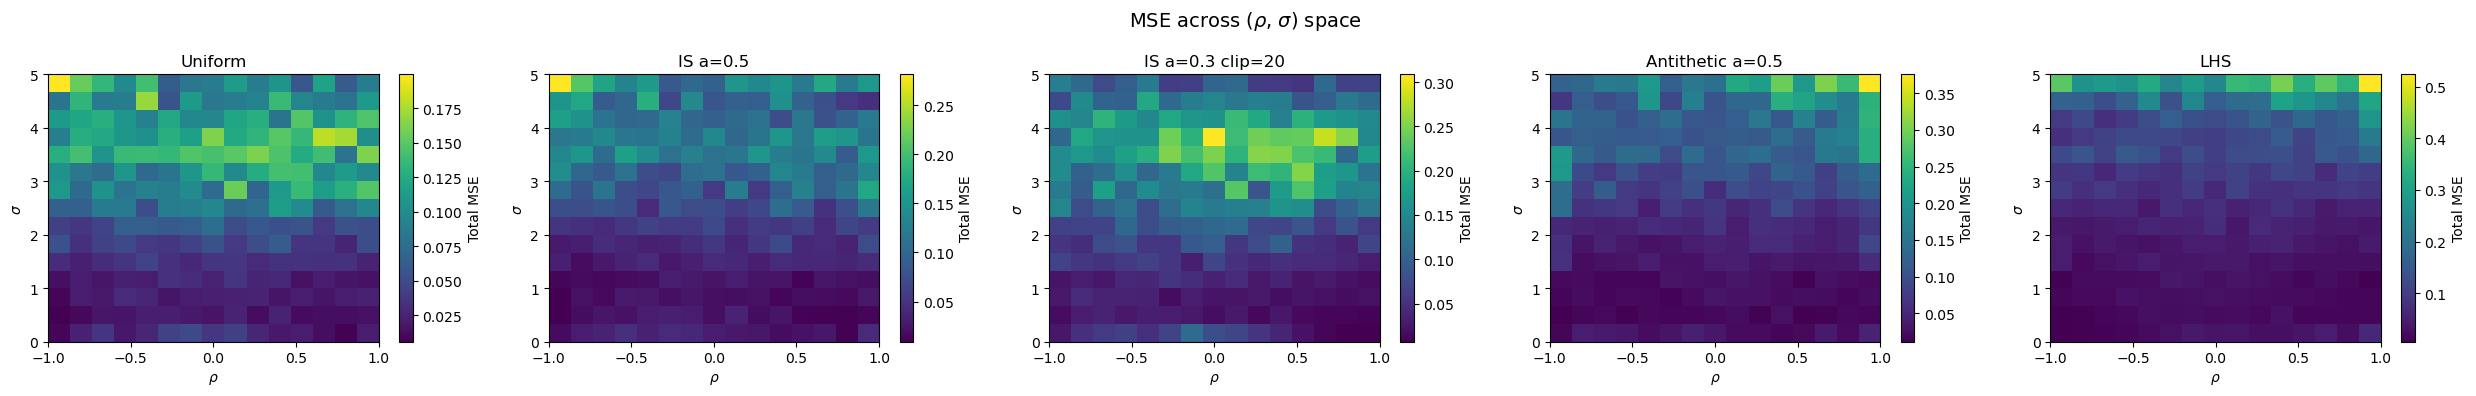

In [8]:
# 2D MSE heatmaps for spatial analysis
theta_true = test_set[0].numpy()
preds = {}
for name, model in final_models.items():
    model.eval()
    with torch.no_grad():
        d = next(model.parameters()).device
        preds[name] = model(test_set[1].to(d)).cpu().numpy()

heatmap_2d(theta_true, preds, [r'$\rho$', r'$\sigma$'],
           param_ranges=[(-1, 1), (0, A)])

## 7. Output Reparameterisation: Predict Marginal SD Instead of $\sigma$

The techniques above all try to fix the *training distribution*. But the core issue is different: when $|\rho| \to 1$, the process is near a unit root and $\sigma$ becomes **statistically non-identifiable** — different $\sigma$ values produce nearly indistinguishable time series. More training samples in that region can't fix what the data itself doesn't contain.

**Key insight:** The *marginal standard deviation* $\text{sd}_x = \sigma / \sqrt{1 - \rho^2}$ **is** directly readable from the data — it's just the sample standard deviation of the time series. So we reparameterise the model output:

$$\text{Model predicts: } (\rho, \;\log \text{sd}_x) \quad \text{instead of } (\rho,\; \sigma)$$

At test time we map back: $\hat\sigma = \exp(\widehat{\log \text{sd}_x}) \cdot \sqrt{1 - \hat\rho^2}$.

**Why this helps:** Both outputs are now "easy" — $\rho$ is estimated from autocorrelation, $\text{sd}_x$ from the sample variance. The hard coupling between $\rho$ and $\sigma$ estimation is broken. Training in log-space also keeps the loss balanced (raw $\text{sd}_x$ ranges from ~0 to ~35).

Training reparameterised model (uniform)...
  Reparam test MSE — rho: 0.0129, sigma: 0.4138, total: 0.4267
  Baseline test MSE — rho: 0.0132, sigma: 0.0595, total: 0.0728


C:\Users\kaima\AppData\Local\Temp\ipykernel_46112\4281982481.py:77: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot(centres, mse_rho_binned, 'o-', label=label, linestyle=ls, markersize=4)
C:\Users\kaima\AppData\Local\Temp\ipykernel_46112\4281982481.py:78: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(centres, mse_sig_binned, 'o-', label=label, linestyle=ls, markersize=4)


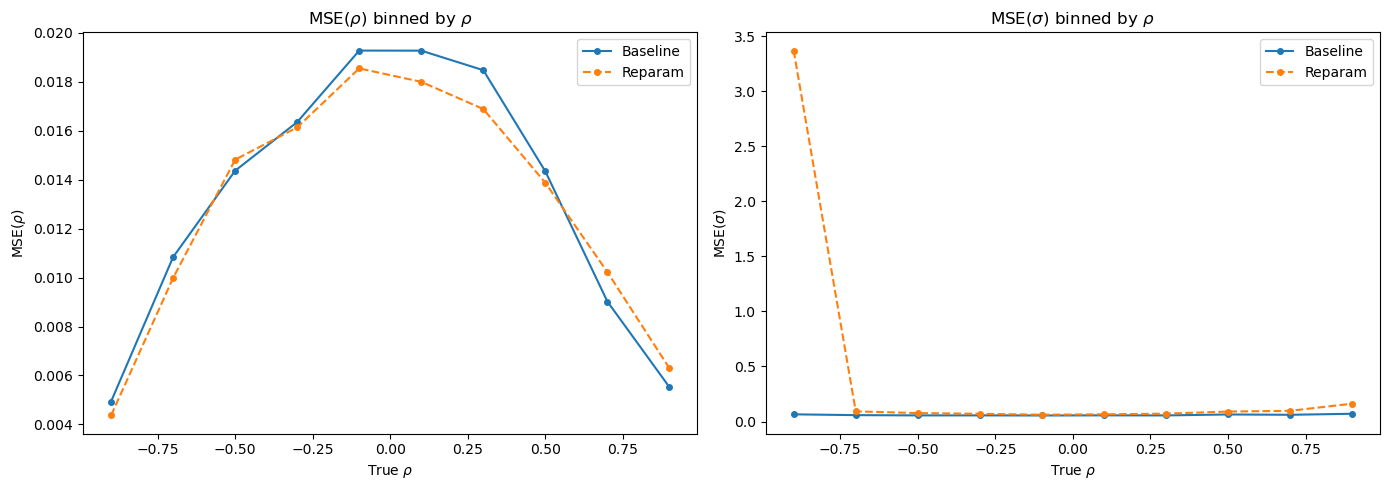

In [9]:
# --- Reparameterised sampler: targets are (rho, log marginal_sd) ---
def sample_uniform_reparam(batch_size):
    rho = torch.empty(batch_size).uniform_(-1, 1)
    sigma = torch.empty(batch_size).uniform_(0, A)
    x = simulate_ar1_batch(rho, sigma, T)
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    marginal_sd = sigma / torch.sqrt(1 - rho_safe**2)
    log_msd = torch.log(marginal_sd + 1e-8)
    theta_reparam = torch.stack([rho, log_msd], dim=1)
    return theta_reparam, x

# --- Model: predicts (tanh -> rho, raw -> log_msd) ---
class AR1EstimatorReparam(GRUEstimator):
    def alter_outputs(self, x):
        rho = torch.tanh(x[:, 0])
        log_msd = x[:, 1]  # raw output = log(marginal_sd)
        return torch.stack([rho, log_msd], dim=1)

# --- Wrapper: converts (rho, log_msd) -> (rho, sigma) for evaluation ---
class ReparamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        rho = out[:, 0]
        log_msd = out[:, 1]
        sigma = torch.exp(log_msd) * torch.sqrt(1 - rho**2 + 1e-8)
        return torch.stack([rho, sigma], dim=1)

# --- Train reparameterised model ---
print("Training reparameterised model (uniform)...")
model_reparam = AR1EstimatorReparam()
model_reparam, history_reparam = train(
    model_reparam, sample_uniform_reparam,
    n_epochs=N_EPOCHS, n_batches=N_BATCHES, lr=LR, seed=0, verbose=False)

# Wrap for evaluation in (rho, sigma) space
model_reparam_wrapped = ReparamWrapper(model_reparam)

# Evaluate: compute test MSE in original (rho, sigma) space
dev = next(model_reparam.parameters()).device
model_reparam_wrapped.eval()
with torch.no_grad():
    pred_reparam = model_reparam_wrapped(test_set[1].to(dev)).cpu().numpy()
theta_true = test_set[0].numpy()
mse_rho = np.mean((pred_reparam[:, 0] - theta_true[:, 0])**2)
mse_sig = np.mean((pred_reparam[:, 1] - theta_true[:, 1])**2)
print(f"  Reparam test MSE — rho: {mse_rho:.4f}, sigma: {mse_sig:.4f}, total: {mse_rho+mse_sig:.4f}")

# --- Compare with standard baseline ---
baseline = seed_results['Uniform']['best_model']
baseline.eval()
with torch.no_grad():
    pred_baseline = baseline(test_set[1].to(dev)).cpu().numpy()
mse_rho_b = np.mean((pred_baseline[:, 0] - theta_true[:, 0])**2)
mse_sig_b = np.mean((pred_baseline[:, 1] - theta_true[:, 1])**2)
print(f"  Baseline test MSE — rho: {mse_rho_b:.4f}, sigma: {mse_sig_b:.4f}, total: {mse_rho_b+mse_sig_b:.4f}")

# --- Binned MSE comparison: the key diagnostic ---
n_bins = 10
rho_true = theta_true[:, 0]
edges = np.linspace(-1, 1, n_bins + 1)
centres = (edges[:-1] + edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, pred, ls in [('Baseline', pred_baseline, '-'), ('Reparam', pred_reparam, '--')]:
    mse_rho_binned = np.zeros(n_bins)
    mse_sig_binned = np.zeros(n_bins)
    for b in range(n_bins):
        mask = (rho_true >= edges[b]) & (rho_true < edges[b+1])
        if mask.sum() > 0:
            mse_rho_binned[b] = np.mean((pred[mask, 0] - theta_true[mask, 0])**2)
            mse_sig_binned[b] = np.mean((pred[mask, 1] - theta_true[mask, 1])**2)
    axes[0].plot(centres, mse_rho_binned, 'o-', label=label, linestyle=ls, markersize=4)
    axes[1].plot(centres, mse_sig_binned, 'o-', label=label, linestyle=ls, markersize=4)

axes[0].set_xlabel(r'True $\rho$'); axes[0].set_ylabel(r'MSE($\rho$)')
axes[0].set_title(r'MSE($\rho$) binned by $\rho$'); axes[0].legend()
axes[1].set_xlabel(r'True $\rho$'); axes[1].set_ylabel(r'MSE($\sigma$)')
axes[1].set_title(r'MSE($\sigma$) binned by $\rho$'); axes[1].legend()
plt.tight_layout(); plt.show()

Training Reparam + IS a=0.5...

Model                       MSE(rho)   MSE(sigma)      Total
-----------------------------------------------------------
Baseline                      0.0132       0.0595     0.0728
Reparam                       0.0129       0.4138     0.4267
Reparam + IS                  0.0130       0.2967     0.3097


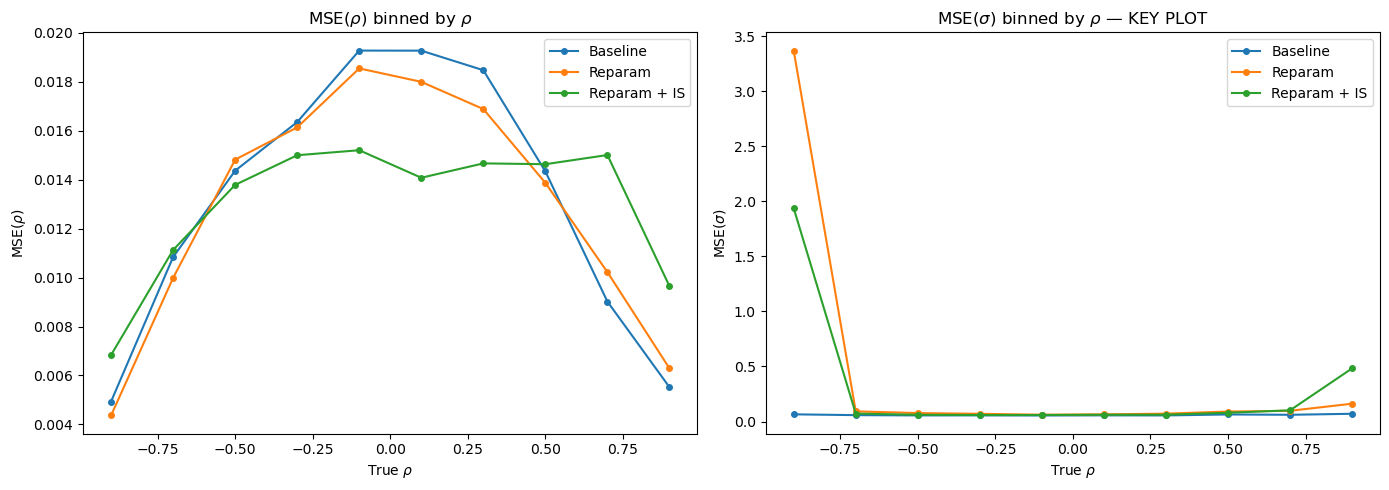

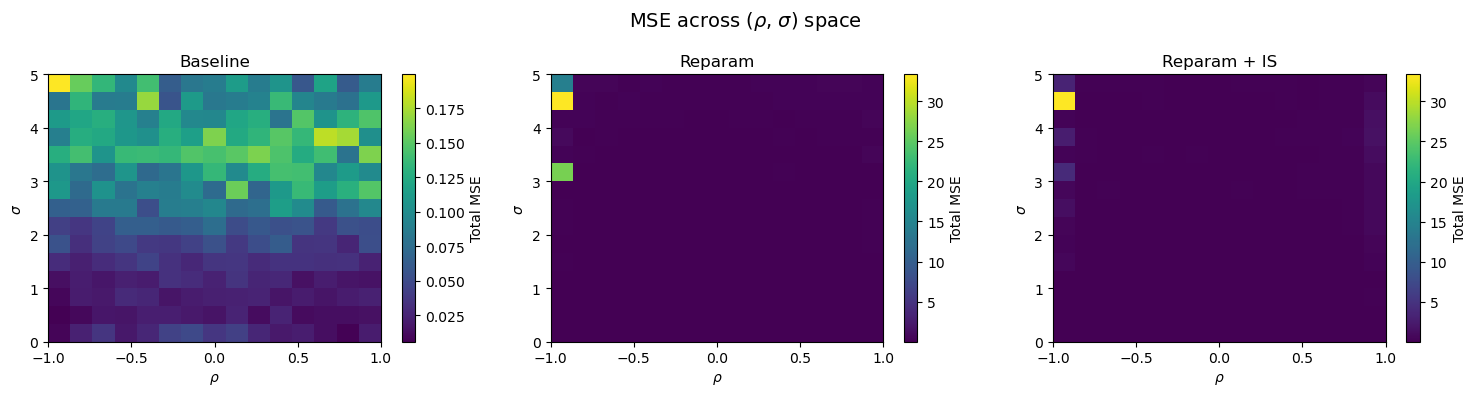

In [10]:
# --- Reparam + IS: now that targets are decoupled, does IS help on top? ---
def sample_is_reparam(batch_size, alpha_rho=0.5, alpha_sigma=0.5):
    """IS with reparameterised targets."""
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, 1.0, size=batch_size)
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32)
    x = simulate_ar1_batch(rho, sigma, T)
    # Reparameterised target
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    log_msd = torch.log(sigma / torch.sqrt(1 - rho_safe**2) + 1e-8)
    theta = torch.stack([rho, log_msd], dim=1)
    # Weights
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho)
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, 1.0)
    weights = torch.tensor(1.0 / (q_rho * q_sigma), dtype=torch.float32)
    return theta, x, weights

# Test set in reparam space (for training loss tracking)
reparam_test = sample_uniform_reparam(8192)

print("Training Reparam + IS a=0.5...")
model_reparam_is = AR1EstimatorReparam()
model_reparam_is, history_reparam_is = train(
    model_reparam_is, lambda bs: sample_is_reparam(bs, 0.5, 0.5),
    n_epochs=N_EPOCHS, n_batches=N_BATCHES, lr=LR, seed=0,
    test_set=reparam_test, verbose=False)

model_reparam_is_wrapped = ReparamWrapper(model_reparam_is)

# --- Final comparison: Baseline vs Reparam vs Reparam+IS ---
all_preds = {}
for label, model in [('Baseline', baseline),
                     ('Reparam', model_reparam_wrapped),
                     ('Reparam + IS', model_reparam_is_wrapped)]:
    model.eval()
    with torch.no_grad():
        all_preds[label] = model(test_set[1].to(dev)).cpu().numpy()

# MSE table
print(f"\n{'Model':25s} {'MSE(rho)':>10s} {'MSE(sigma)':>12s} {'Total':>10s}")
print('-' * 59)
for label, pred in all_preds.items():
    mr = np.mean((pred[:, 0] - theta_true[:, 0])**2)
    ms = np.mean((pred[:, 1] - theta_true[:, 1])**2)
    print(f"{label:25s} {mr:10.4f} {ms:12.4f} {mr+ms:10.4f}")

# Binned MSE — the key diagnostic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, pred in all_preds.items():
    mse_rho_binned = np.zeros(n_bins)
    mse_sig_binned = np.zeros(n_bins)
    for b in range(n_bins):
        mask = (rho_true >= edges[b]) & (rho_true < edges[b+1])
        if mask.sum() > 0:
            mse_rho_binned[b] = np.mean((pred[mask, 0] - theta_true[mask, 0])**2)
            mse_sig_binned[b] = np.mean((pred[mask, 1] - theta_true[mask, 1])**2)
    axes[0].plot(centres, mse_rho_binned, 'o-', label=label, markersize=4)
    axes[1].plot(centres, mse_sig_binned, 'o-', label=label, markersize=4)

axes[0].set_xlabel(r'True $\rho$'); axes[0].set_ylabel(r'MSE($\rho$)')
axes[0].set_title(r'MSE($\rho$) binned by $\rho$'); axes[0].legend()
axes[1].set_xlabel(r'True $\rho$'); axes[1].set_ylabel(r'MSE($\sigma$)')
axes[1].set_title(r'MSE($\sigma$) binned by $\rho$ — KEY PLOT'); axes[1].legend()
plt.tight_layout(); plt.show()

# 2D heatmap
heatmap_2d(theta_true, all_preds, [r'$\rho$', r'$\sigma$'],
           param_ranges=[(-1, 1), (0, A)])

## 8. Self-Normalised vs Unnormalised IS Loss

The IS loss can be computed two ways:

**Unnormalised** (as in `working_13_3_IS.ipynb`):
$$\hat{L}_\text{unorm} = \frac{1}{N}\sum_{i=1}^{N} w_i \lVert f_\phi(x_i) - \theta_i\rVert^2$$

**Self-normalised** (as in `sbi.train()` default):
$$\hat{L}_\text{snorm} = \frac{\sum_{i=1}^{N} w_i \lVert f_\phi(x_i) - \theta_i\rVert^2}{\sum_{i=1}^{N} w_i}$$

These differ by a factor of $\bar{w} = \frac{1}{N}\sum w_i$. Self-normalisation stabilises the loss scale but changes the effective learning rate each batch. Unnormalised preserves the true gradient direction but can have larger magnitude swings.

We also include the **mild alpha range** (0.8, 0.9) that `working_13_3_IS.ipynb` found to be the sweet spot.

In [11]:
# Reload train to pick up the new normalize_weights parameter
import importlib
import sbi.train as _train_mod
importlib.reload(_train_mod)
from sbi.train import train

alpha_range = [1.0, 0.9, 0.8, 0.7, 0.5]

norm_models, norm_histories = {}, {}
unnorm_models, unnorm_histories = {}, {}

for alpha in alpha_range:
    fn = (lambda bs, a=alpha: sample_is(bs, a, a)) if alpha < 1.0 else sample_uniform
    label = f'a={alpha}' if alpha < 1.0 else 'Uniform'

    # Self-normalised
    m, h = train(AR1Estimator(), fn, n_epochs=N_EPOCHS, n_batches=N_BATCHES,
                 lr=LR, seed=0, test_set=test_set, verbose=False,
                 normalize_weights=True)
    norm_models[label] = m
    norm_histories[label] = h

    # Unnormalised
    m2, h2 = train(AR1Estimator(), fn, n_epochs=N_EPOCHS, n_batches=N_BATCHES,
                   lr=LR, seed=0, test_set=test_set, verbose=False,
                   normalize_weights=False)
    unnorm_models[label] = m2
    unnorm_histories[label] = h2

    print(f"{label:10s}  self-norm: {h[-1]:.4f}   unnorm: {h2[-1]:.4f}")

# --- Learning curves side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for label, h in norm_histories.items():
    axes[0].plot(h, label=label)
axes[0].set_yscale('log'); axes[0].set_title('Self-Normalised IS')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test MSE')
axes[0].legend(fontsize=8); axes[0].grid(True, which='both', ls='--', lw=0.5)

for label, h in unnorm_histories.items():
    axes[1].plot(h, label=label)
axes[1].set_yscale('log'); axes[1].set_title('Unnormalised IS')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8); axes[1].grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout(); plt.show()

ImportError: module train not in sys.modules

In [ ]:
# --- MSE table: self-norm vs unnorm for each alpha ---
theta_true = test_set[0].numpy()

print(f"{'Method':30s} {'MSE(rho)':>10s} {'MSE(sigma)':>12s} {'Total':>10s}")
print('-' * 64)

all_results = {}
for label in alpha_range:
    key = f'a={label}' if label < 1.0 else 'Uniform'
    for mode, models_dict in [('self-norm', norm_models), ('unnorm', unnorm_models)]:
        model = models_dict[key]
        model.eval()
        with torch.no_grad():
            d = next(model.parameters()).device
            pred = model(test_set[1].to(d)).cpu().numpy()
        mr = np.mean((pred[:, 0] - theta_true[:, 0])**2)
        ms = np.mean((pred[:, 1] - theta_true[:, 1])**2)
        name = f'{key} ({mode})'
        print(f"{name:30s} {mr:10.4f} {ms:12.4f} {mr+ms:10.4f}")
        all_results[name] = pred

# --- Find best from each mode ---
def total_mse(pred):
    return np.mean((pred - theta_true)**2)

best_norm_label = min(norm_models.keys(),
                      key=lambda k: total_mse(all_results[f'{k} (self-norm)']))
best_unnorm_label = min(unnorm_models.keys(),
                        key=lambda k: total_mse(all_results[f'{k} (unnorm)']))

print(f"\nBest self-norm: {best_norm_label}")
print(f"Best unnorm:    {best_unnorm_label}")

# --- Binned MSE comparison ---
rho_true = theta_true[:, 0]
n_bins = 10
edges = np.linspace(-1, 1, n_bins + 1)
centres = (edges[:-1] + edges[1:]) / 2

compare_preds = {
    f'Self-norm ({best_norm_label})': all_results[f'{best_norm_label} (self-norm)'],
    f'Unnorm ({best_unnorm_label})':  all_results[f'{best_unnorm_label} (unnorm)'],
    'Uniform baseline':               all_results['Uniform (self-norm)'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, pred in compare_preds.items():
    mse_rho_binned = np.zeros(n_bins)
    mse_sig_binned = np.zeros(n_bins)
    for b in range(n_bins):
        mask = (rho_true >= edges[b]) & (rho_true < edges[b+1])
        if mask.sum() > 0:
            mse_rho_binned[b] = np.mean((pred[mask, 0] - theta_true[mask, 0])**2)
            mse_sig_binned[b] = np.mean((pred[mask, 1] - theta_true[mask, 1])**2)
    axes[0].plot(centres, mse_rho_binned, 'o-', label=label, markersize=4)
    axes[1].plot(centres, mse_sig_binned, 'o-', label=label, markersize=4)

axes[0].set_xlabel(r'True $\rho$'); axes[0].set_ylabel(r'MSE($\rho$)')
axes[0].set_title(r'MSE($\rho$) binned by $\rho$'); axes[0].legend(fontsize=8)
axes[1].set_xlabel(r'True $\rho$'); axes[1].set_ylabel(r'MSE($\sigma$)')
axes[1].set_title(r'MSE($\sigma$) binned by $\rho$'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

| Technique | Mechanism | Pros | Cons |
|---|---|---|---|
| **Uniform** | Standard MC | Simple, unbiased | Under-represents boundaries |
| **IS (Beta)** | Reweight to oversample boundaries | Better boundary coverage | High-variance weights can destabilise training |
| **IS + Clipping** | Cap extreme weights | Stabilises aggressive IS | Introduces bias |
| **Antithetic IS** | Pair $(u, 1-u)$ samples | Reduces batch-to-batch variance | Implementation complexity; benefit depends on loss symmetry |
| **LHS** | Stratified coverage, no weights | Guaranteed coverage; no weight variance | No boundary emphasis; doesn't target specific regions |
| **Reparameterisation** | Predict $(\rho, \log\text{sd}_x)$ instead of $(\rho, \sigma)$ | Decouples estimation; both outputs directly observable from data | Adds back-transformation step; error propagation at extreme $\rho$ |

**Key takeaways:**
- Sections 1–5 show that sampling-distribution changes (IS, LHS, etc.) cannot fix the fundamental issue: $\sigma$ is statistically hard to identify when $|\rho| \to 1$
- Section 7 addresses the root cause by reparameterising to $\text{sd}_x = \sigma/\sqrt{1-\rho^2}$, which the network can directly read from the data's sample variance